<a href="https://colab.research.google.com/github/soledad-villarrubia/Data_Sciense_3/blob/main/Proyecto_Final_Ciencia_de_Datos_IIi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Data Science III: NLP & Deep Learning

Autor: Villarrubia Dos Santos Soledad Magalí
Comisión: 90480

## Análisis de sentimiento en reseñas de películas en español utilizando técnicas de NLP y Machine Learning

##Introducción

En este trabajo se desarrolla un análisis de sentimiento sobre reseñas de películas escritas en español, utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning.

El objetivo principal es identificar automáticamente si una reseña expresa un sentimiento positivo o negativo. Para ello, se trabaja con un dataset de Filmaffinity obtenido desde Kaggle, que contiene opiniones reales de usuarios y un puntaje asociado a cada reseña.

A lo largo del trabajo se realizará la carga y exploración de los datos, la limpieza del texto, la construcción de una variable objetivo, la vectorización del lenguaje y el entrenamiento de un modelo de clasificación. Finalmente, se evaluarán los resultados obtenidos y se presentarán conclusiones y posibles mejoras futuras.

## Descripción del problema

En el contexto actual, las plataformas de contenido reciben una gran cantidad de reseñas por parte de los usuarios. Analizar manualmente estas opiniones resulta complejo y poco eficiente.

El problema que se busca resolver es la clasificación automática de reseñas de películas según su sentimiento, permitiendo identificar si una opinión es positiva o negativa de forma automatizada.

##Objetivo general
Desarrollar un modelo de clasificación de texto capaz de identificar el sentimiento de reseñas de películas utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Machine Learning.

## Origen de los datos
El dataset utilizado proviene de la plataforma Filmaffinity y contiene reseñas de películas junto con una puntuación asociada a cada opinión.

A partir de esta puntuación, se construyó una variable de sentimiento para poder aplicar modelos de clasificación supervisada.

## Definición de variables
- review: texto de la reseña realizada por el usuario  
- review_limpia: versión preprocesada del texto  
- label: puntuación original de la reseña  
- sentiment: variable objetivo (positivo / negativo)

## Librerías a utilizar
En esta sección se presentan las librerías utilizadas a lo largo del proyecto.

Se emplean herramientas para la manipulación de datos, visualización, procesamiento de lenguaje natural (NLP), vectorización de texto y entrenamiento de modelos de Machine Learning.

In [1]:
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import os
import re
import random
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# CONFIGURACIÓN GENERAL

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Recursos de NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("Librerías cargadas correctamente.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Librerías cargadas correctamente.


In [2]:
import requests

url = "https://raw.githubusercontent.com/soledad-villarrubia/Data_Sciense_3/refs/heads/main/reviews_filmaffinity.csv"


response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

df = pd.read_csv(url, sep=';', encoding='latin1')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

# The original data does not contain a column named 'tweet_id,label,tweet_text'.
# Instead, it contains 'review_text' and 'review_rate'.
# We will rename 'review_text' to 'tweet_text' and 'review_rate' to 'label'
# to align with the subsequent processing steps.
df.rename(columns={'review_text': 'tweet_text', 'review_rate': 'label'}, inplace=True)



df['label'] = pd.to_numeric(df['label'], errors='coerce')

df.dropna(inplace=True)

df.head()

film_name;gender;film_avg_rate;review_rate;review_title;review_text;;;;;
Ocho apellidos vascos;Comedia;6;3;OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO;"La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la anda


,film_name,gender,film_avg_rate,label,review_title,tweet_text
0,Ocho apellidos vascos,Comedia,6,3.0,OCHO APELLIDOS VASCOS...Y NINGÃN NOMBRE PROPIO,La mayor virtud de esta pelÃ­cula es su existe...
1,Ocho apellidos vascos,Comedia,6,2.0,El perro verde,"No soy un experto cinÃ©filo, pero pocas veces ..."
2,Ocho apellidos vascos,Comedia,6,2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,6,2.0,Aida: The movie,"No sÃ© quÃ© estÃ¡ pasando, si la gente se deja..."
4,Ocho apellidos vascos,Comedia,6,2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"Pero cuando amanece,y me quedo solo,siento en ..."


##  Exploración inicial del dataset

Antes de entrenar cualquier modelo, es importante conocer cómo está compuesto el dataset. En esta etapa se analiza la cantidad de filas y columnas, los nombres de las variables, los tipos de datos y la posible existencia de valores nulos.

In [3]:
# Vemos cuántas filas y columnas tiene el dataset
# Esto nos da una idea del tamaño con el que vamos a trabajar
df.shape

(8592, 6)

In [4]:
# Mostramos los nombres de las columnas para identificar qué información trae el archivo
df.columns

Index(['film_name', 'gender', 'film_avg_rate', 'label', 'review_title',
       'tweet_text'],
      dtype='object')

In [5]:
# Acá vemos el tipo de dato de cada columna
# También nos dice si hay valores no nulos en cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8592 entries, 0 to 8602
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   film_name      8592 non-null   object 
 1   gender         8592 non-null   object 
 2   film_avg_rate  8592 non-null   object 
 3   label          8592 non-null   float64
 4   review_title   8592 non-null   object 
 5   tweet_text     8592 non-null   object 
dtypes: float64(1), object(5)
memory usage: 469.9+ KB


In [6]:
# Revisamos si hay datos faltantes o nulos
# Esto es importante porque los nulos pueden romper análisis o modelos
df.isnull().sum()

,0
film_name,0
gender,0
film_avg_rate,0
label,0
review_title,0
tweet_text,0


In [7]:
# Definimos una función para clasificar mejor los sentimientos
def clasificar_sentimiento(x):
    # Si la puntuación es alta, consideramos que es positivo
    if x >= 4:
        return 'positivo'
    # Si es baja, negativo
    elif x <= 2:
        return 'negativo'
    # Si está en el medio, lo consideramos neutral
    else:
        return 'neutral'

# Aplicamos la función a la columna label para crear la columna 'sentiment'
df['sentiment'] = df['label'].apply(clasificar_sentimiento)

# Eliminamos los casos neutrales para simplificar el problema a binario
df = df[df['sentiment'] != 'neutral']

# Verificamos cómo quedó la distribución
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1160


In [8]:
# Mostramos 3 filas completas para ver mejor el contenido real del dataset
df.head(3)

,film_name,gender,film_avg_rate,label,review_title,tweet_text,sentiment
1,Ocho apellidos vascos,Comedia,6,2.0,El perro verde,"No soy un experto cinÃ©filo, pero pocas veces ...",negativo
2,Ocho apellidos vascos,Comedia,6,2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...,negativo
3,Ocho apellidos vascos,Comedia,6,2.0,Aida: The movie,"No sÃ© quÃ© estÃ¡ pasando, si la gente se deja...",negativo


 Preparación de la variable objetivo

Para resolver un problema de clasificación, es necesario contar con una variable objetivo clara. En este caso, se trabaja con el sentimiento asociado a cada reseña, clasificándolo en categorías positivas y negativas.

In [9]:
# Este bloque transforma la columna numérica (label) en una variable de sentimiento
# Lo hacemos porque los modelos de clasificación necesitan etiquetas claras como "positivo" o "negativo"

# Definimos una función para clasificar mejor los sentimientos
def clasificar_sentimiento(x):
    # Si la puntuación es alta, consideramos que es positivo
    if x >= 4:
        return 'positivo'

    # Si es baja, negativo
    elif x <= 2:
        return 'negativo'

    # Si está en el medio, lo consideramos neutral
    else:
        return 'neutral'

# Aplicamos la función a la columna label
df['sentiment'] = df['label'].apply(clasificar_sentimiento)

# Mostramos cómo quedó la nueva columna
df[['label', 'sentiment']].head()

,label,sentiment
1,2.0,negativo
2,2.0,negativo
3,2.0,negativo
4,2.0,negativo
5,8.0,positivo


In [10]:
# Contamos cuántos casos hay de cada tipo de sentimiento
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1160


Se observa que el dataset presenta un desbalance en la variable objetivo, con una mayor cantidad de reseñas positivas en comparación con las negativas y neutrales.

Para simplificar el problema y mejorar el rendimiento del modelo, se decidió trabajar con una clasificación binaria (positivo vs negativo), eliminando los casos neutrales.

Este enfoque es común en problemas de análisis de sentimiento, ya que permite obtener modelos más robustos y fáciles de interpretar.

In [11]:
# Renombramos la columna de texto para trabajar de forma más clara
df = df.rename(columns={'tweet_text': 'review'})

Selección de variables relevantes

Una vez definida la variable objetivo, se procede a seleccionar únicamente las columnas necesarias para el análisis.

En este caso, se trabaja exclusivamente con el texto de la reseña (review) y la variable de clasificación (sentiment), eliminando el resto de las variables para simplificar el dataset y mejorar la eficiencia del modelo.

In [12]:
# Nos quedamos solo con las columnas necesarias para el modelo
# review: texto de la reseña
# sentiment: variable objetivo
df = df[['review', 'sentiment']].copy()

# Verificamos cómo quedó el dataset
df.head()

,review,sentiment
1,"No soy un experto cinÃ©filo, pero pocas veces ...",negativo
2,Si no eres un incondicional del humor estilo T...,negativo
3,"No sÃ© quÃ© estÃ¡ pasando, si la gente se deja...",negativo
4,"Pero cuando amanece,y me quedo solo,siento en ...",negativo
5,La llegada de Rafa a Euskadi es como ponerse a...,positivo


In [13]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [14]:
# Eliminamos los casos neutrales porque no aportan claridad al modelo
df = df[df['sentiment'] != 'neutral']

# Volvemos a ver la distribución
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1160


In [15]:
# Verificamos nuevamente la distribución final
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
positivo,0.853127
negativo,0.146873


Limpieza y normalización del texto

En esta etapa se realiza la limpieza del texto de las reseñas. Este paso es fundamental en el procesamiento de lenguaje natural, ya que permite eliminar ruido y estandarizar la información.

Se aplican transformaciones como pasar todo a minúsculas, eliminar signos de puntuación, caracteres especiales y espacios innecesarios. Esto facilita que el modelo identifique patrones de manera más eficiente.

In [16]:
# Mostramos todas las columnas del dataset para ver cómo se llama realmente la columna de texto
df.columns

Index(['review', 'sentiment'], dtype='object')

In [17]:
# Renombramos la columna de texto para trabajar con un nombre más claro y estándar
df = df.rename(columns={'tweet_text': 'review'})

# Verificamos que el cambio se haya hecho correctamente
df.columns

Index(['review', 'sentiment'], dtype='object')

In [18]:
# Verificamos si hay valores nulos en la columna de texto
df['review'].isnull().sum()

np.int64(0)

Se verificó la existencia de valores nulos en la variable de texto.
No se encontraron registros vacíos, por lo que no fue necesario realizar imputaciones ni eliminaciones en esta etapa.

Limpieza y normalización del texto

En esta etapa se realiza la limpieza de las reseñas con el objetivo de mejorar la calidad de los datos antes de entrenar el modelo.

En los problemas de procesamiento de lenguaje natural (NLP), los textos suelen contener ruido, como mayúsculas, signos de puntuación, números o espacios innecesarios, que no aportan información relevante al modelo.

Por este motivo, se aplican distintas transformaciones para estandarizar el texto:

- Se convierten todos los caracteres a minúsculas
- Se eliminan signos de puntuación y caracteres especiales
- Se eliminan espacios duplicados
- Se generan nuevas variables con el texto limpio

Estas acciones permiten que el modelo identifique patrones de manera más eficiente y mejore su rendimiento.

In [19]:
# Eliminamos posibles valores nulos en la columna de texto
# Aunque ya verificamos que no hay, esto se hace por buenas prácticas
df = df.dropna(subset=['review'])

In [20]:
# Convertimos todo el texto a minúsculas
# Esto evita que el modelo interprete como distintas palabras "Bueno" y "bueno"
df['review'] = df['review'].str.lower()

In [21]:
# Importamos la librería re para trabajar con expresiones regulares
import re

# Creamos una función para limpiar el texto
# Esta función elimina caracteres que no sean letras y también espacios innecesarios
def limpiar_texto(texto):
    texto = str(texto)  # Nos aseguramos que el dato sea texto

    # Eliminamos todo lo que no sea letras (incluye acentos)
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)

    # Eliminamos espacios repetidos
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicamos la función a la columna review y creamos una nueva columna limpia
df['review_limpia'] = df['review'].apply(limpiar_texto)

In [22]:
# Mostramos algunas filas para comparar el texto original vs el limpio
df[['review', 'review_limpia']].head(3)

,review,review_limpia
1,"no soy un experto cinã©filo, pero pocas veces ...",no soy un experto cin filo pero pocas veces me...
2,si no eres un incondicional del humor estilo t...,si no eres un incondicional del humor estilo t...
3,"no sã© quã© estã¡ pasando, si la gente se deja...",no s qu est pasando si la gente se deja llevar...


In [23]:
# Eliminamos filas donde el texto haya quedado vacío después de la limpieza
# Esto puede pasar si la reseña tenía solo símbolos o caracteres raros
df = df[df['review_limpia'].str.strip() != '']

# Verificamos el tamaño final del dataset
df.shape

(7898, 3)

In [24]:
# Importamos la función para dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Separamos la variable de entrada (X) y la variable objetivo (y)
# X contiene el texto limpio
# y contiene la clase que queremos predecir
X = df['review_limpia']
y = df['sentiment']

# Dividimos los datos
# X es el texto limpio
# y es la variable objetivo
# test_size=0.2 significa que el 20% de los datos se usa para prueba
# random_state=42 hace que el resultado sea siempre el mismo
# stratify=y mantiene la proporción de positivos y negativos en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mostramos cuántos datos quedaron en entrenamiento y cuántos en prueba
print("Cantidad de reseñas para entrenamiento:", len(X_train))
print("Cantidad de reseñas para prueba:", len(X_test))


Cantidad de reseñas para entrenamiento: 6318
Cantidad de reseñas para prueba: 1580


## ETAPA 1: Procesamiento de Lenguaje Natural (NLP)

## Tokenización del texto

En esta etapa se transforma cada reseña en una lista de palabras (tokens).

Esto permite trabajar el texto de manera más estructurada, facilitando la aplicación de técnicas posteriores como la eliminación de palabras irrelevantes o el análisis de frecuencia.

In [25]:
# Convertimos cada reseña en una lista de palabras
# Esto se conoce como tokenización
df['tokens'] = df['review_limpia'].apply(lambda x: x.split())

# Mostramos un ejemplo
df[['review_limpia', 'tokens']].head(3)

,review_limpia,tokens
1,no soy un experto cin filo pero pocas veces me...,"[no, soy, un, experto, cin, filo, pero, pocas,..."
2,si no eres un incondicional del humor estilo t...,"[si, no, eres, un, incondicional, del, humor, ..."
3,no s qu est pasando si la gente se deja llevar...,"[no, s, qu, est, pasando, si, la, gente, se, d..."


## Eliminación de stopwords

Las stopwords son palabras muy frecuentes en el idioma (como "el", "la", "de", "y") que no aportan significado relevante al análisis.

Por este motivo, se eliminan para mejorar la calidad de los datos y permitir que el modelo se enfoque en palabras más importantes.

In [26]:
from nltk.corpus import stopwords

# Definimos las palabras vacías en español
stop_words = set(stopwords.words('spanish'))

# Eliminamos stopwords de cada reseña
df['tokens_sin_stopwords'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

# Mostramos resultado
df[['tokens', 'tokens_sin_stopwords']].head(3)

,tokens,tokens_sin_stopwords
1,"[no, soy, un, experto, cin, filo, pero, pocas,...","[experto, cin, filo, pocas, veces, hab, tan, j..."
2,"[si, no, eres, un, incondicional, del, humor, ...","[si, incondicional, humor, estilo, tele, si, t..."
3,"[no, s, qu, est, pasando, si, la, gente, se, d...","[s, qu, est, pasando, si, gente, deja, llevar,..."


## Lematización del texto

La lematización permite reducir las palabras a su forma base o raíz, lo que ayuda a unificar términos similares y mejorar el análisis del texto.


In [27]:
from nltk.stem import WordNetLemmatizer

# Inicializamos el lematizador
lemmatizer = WordNetLemmatizer()

# Aplicamos lematización sobre los tokens sin stopwords
df['tokens_lematizados'] = df['tokens_sin_stopwords'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

# Mostramos ejemplo
df[['tokens_sin_stopwords', 'tokens_lematizados']].head(3)

,tokens_sin_stopwords,tokens_lematizados
1,"[experto, cin, filo, pocas, veces, hab, tan, j...","[experto, cin, filo, pocas, veces, hab, tan, j..."
2,"[si, incondicional, humor, estilo, tele, si, t...","[si, incondicional, humor, estilo, tele, si, t..."
3,"[s, qu, est, pasando, si, gente, deja, llevar,...","[s, qu, est, pasando, si, gente, deja, llevar,..."


## Nube de palabras

Se genera una nube de palabras para visualizar cuáles son los términos más frecuentes en el conjunto de datos.

Las palabras que aparecen con mayor tamaño representan aquellas que tienen mayor frecuencia dentro de las reseñas.

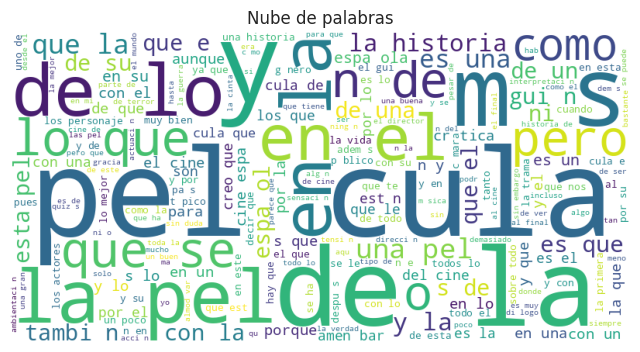

In [28]:
from wordcloud import WordCloud

# Unimos todo el texto en un solo string
texto = " ".join(df['review_limpia'])

# Generamos la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto)

# Mostramos la nube
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Nube de palabras")
plt.show()

## N-gramas

Los N-gramas permiten analizar combinaciones de palabras consecutivas, lo que ayuda a capturar mejor el contexto del texto.

En este caso, se analizan bigramas (combinaciones de dos palabras).

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

# Creamos un vectorizador de bigramas
vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)

# Ajustamos y transformamos el texto
X_ngram = vectorizer.fit_transform(df['review_limpia'])

# Mostramos los bigramas más frecuentes
print(vectorizer.get_feature_names_out())

['de la' 'de los' 'en el' 'en la' 'la pel' 'lo que' 'pel cula' 'que no'
 'que se' 'una pel']


In [30]:
# Creamos un texto limpio SIN stopwords para mejorar los n-gramas
df['texto_ngram'] = df['tokens_sin_stopwords'].apply(lambda x: " ".join(x))

# Creamos el vectorizador de bigramas
vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)

# Ajustamos y transformamos el texto limpio
X_ngram = vectorizer.fit_transform(df['texto_ngram'])

# Mostramos los bigramas más relevantes
print(vectorizer.get_feature_names_out())

['almod var' 'amen bar' 'cine espa' 'cr tica' 'cr ticas' 'espa ol'
 'espa ola' 'est bien' 'pel cula' 'pel culas']


## Análisis de sentimiento

Se construyó una variable de sentimiento a partir de la puntuación original del dataset, clasificando las reseñas como positivas o negativas.

Esto permitió transformar el problema en una tarea de clasificación supervisada, que luego se utiliza en la etapa de modelado.

Se separan las variables de entrada (X) y la variable objetivo (y).
Se utiliza la versión limpia del texto para mejorar el rendimiento del modelo, ya que reduce el ruido presente en los datos originales.

Estas técnicas permiten comprender mejor la estructura y el contenido del texto, facilitando el posterior entrenamiento de modelos de Machine Learning.

In [31]:
# Separamos la variable de entrada (X) y la variable objetivo (y)
# X contiene el texto limpio
# y contiene la clase que queremos predecir

# Nos aseguramos de que exista la columna review_limpia
if 'review_limpia' not in df.columns:
    df['review_limpia'] = df['review'].apply(limpiar_texto)

X = df['review_limpia']
y = df['sentiment']

## ETAPA 2: Modelado y entrenamiento

En esta etapa se transforma el texto en variables numéricas mediante técnicas de vectorización, lo que permite aplicar modelos de Machine Learning para la clasificación del sentimiento.

Luego, se entrena y evalúa el modelo para analizar su desempeño en la predicción de nuevas reseñas.

##Vectorizar con TF-IDF

##Vectorización del texto

Los algoritmos de Machine Learning no pueden trabajar directamente con texto, por lo que es necesario transformar las reseñas en valores numéricos.

Para ello, se utiliza la técnica TF-IDF (Term Frequency - Inverse Document Frequency), que permite representar cada reseña en función de la importancia de las palabras dentro del conjunto de datos.

Esta técnica es muy utilizada en problemas de clasificación de texto, ya que ayuda a destacar las palabras más relevantes y reducir el peso de las más frecuentes pero poco informativas.

In [32]:
# Importamos el vectorizador TF-IDF
# Esto convierte el texto en números según la importancia de las palabras
from sklearn.feature_extraction.text import TfidfVectorizer

# Creamos el vectorizador
# max_features=5000 limita la cantidad de palabras para que el modelo no se vuelva tan pesado
tfidf = TfidfVectorizer(max_features=5000)

# Ajustamos el vectorizador con los textos de entrenamiento
# Esto hace que aprenda las palabras más relevantes
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformamos los textos de prueba usando el mismo vectorizador
X_test_tfidf = tfidf.transform(X_test)

# Mostramos la forma de la matriz resultante
X_train_tfidf.shape

(6318, 5000)

## Representación del texto con Bag of Words (BOW)

Además de TF-IDF, se utiliza la técnica Bag of Words para representar el texto en forma numérica.

Esta técnica se basa en la frecuencia de aparición de palabras dentro del texto, sin considerar el orden ni la importancia relativa de las mismas.

Esto permite comparar diferentes formas de vectorización y analizar su impacto en el rendimiento del modelo.

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Creamos el vectorizador Bag of Words
bow = CountVectorizer(max_features=5000)

# Ajustamos y transformamos el texto
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [34]:
# Entrenamos modelo con Bag of Words
modelo_bow = LogisticRegression(max_iter=1000)
modelo_bow.fit(X_train_bow, y_train)

# Predicciones
y_pred_bow = modelo_bow.predict(X_test_bow)

# Evaluación
print("Accuracy BOW:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

Accuracy BOW: 0.8879746835443038
              precision    recall  f1-score   support

    negativo       0.65      0.53      0.58       232
    positivo       0.92      0.95      0.94      1348

    accuracy                           0.89      1580
   macro avg       0.78      0.74      0.76      1580
weighted avg       0.88      0.89      0.88      1580



##COMPARACIÓN TF-IDF vs BOW

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_tfidf, y_train)

y_pred_lr = modelo_lr.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy TF-IDF:", accuracy_lr)

Accuracy TF-IDF: 0.8848101265822785


In [49]:
# Importamos el vectorizador TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape

(6318, 5000)

In [50]:
resultados = pd.DataFrame({
    'Modelo': ['TF-IDF', 'Bag of Words'],
    'Accuracy': [
        accuracy_lr,
        accuracy_score(y_test, y_pred_bow)
    ]
})

resultados

,Modelo,Accuracy
0,TF-IDF,0.884810
1,Bag of Words,0.887975


## Comparación de técnicas de vectorización

A partir de los resultados obtenidos, se observa que ambas técnicas de vectorización presentan un buen desempeño en la clasificación de las reseñas.

En este caso particular, Bag of Words obtuvo un accuracy levemente superior al de TF-IDF. Esto indica que, para este dataset, la frecuencia de palabras resulta suficiente para capturar los patrones necesarios para la clasificación.

Sin embargo, la diferencia entre ambos modelos no es significativa, por lo que se puede concluir que ambas técnicas son válidas y efectivas para este tipo de problema.

La elección final puede depender del contexto y de las características del dataset, siendo recomendable evaluar ambas alternativas en cada caso.

##Entrenamiento del modelo

En esta etapa se entrena un modelo de clasificación utilizando Regresión Logística.

Este algoritmo es ampliamente utilizado en problemas de análisis de texto, ya que permite identificar patrones en los datos y clasificar nuevas reseñas según su contenido.

Se utiliza como modelo base debido a su buen desempeño y simplicidad de implementación.

## Modelo con PyTorch

En esta sección se implementa una red neuronal utilizando PyTorch, empleando como entrada los vectores TF-IDF generados previamente.

El modelo incluye múltiples capas densas, Batch Normalization y Dropout, lo cual permite mejorar la capacidad de generalización y evitar el sobreajuste.

Se utilizará la función de pérdida CrossEntropyLoss y el optimizador Adam, junto con una estrategia simple de early stopping.

Datos preparados para PyTorch correctamente.
Tamaño train: 5054
Tamaño validación: 1264
Tamaño test: 1580
TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)
Entrenando en: cpu
Época 1/50 | Train Loss: 0.3552 | Train Acc: 0.8532 | Val Loss: 0.3355 | Val Acc: 0.8829
Época 2/50 | Train Loss: 0.1924 | Train Acc: 0.9268 | Val Loss: 0.3266 | Val Acc: 0.8449
Época 3/50 | Train Loss: 0.0987 | Train Acc: 0.9691 | Val Loss: 0.3092 | Val Acc: 0.8576
Época 4/50 | Train Loss: 0.0572 | Train Acc: 0.9820 | Val Loss: 0.3636 | Val Acc: 0.8497
Época 5/50 | Train Loss: 0.0

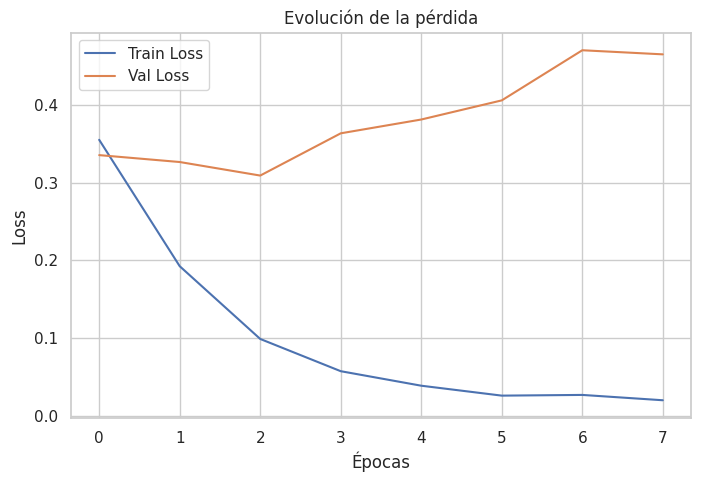

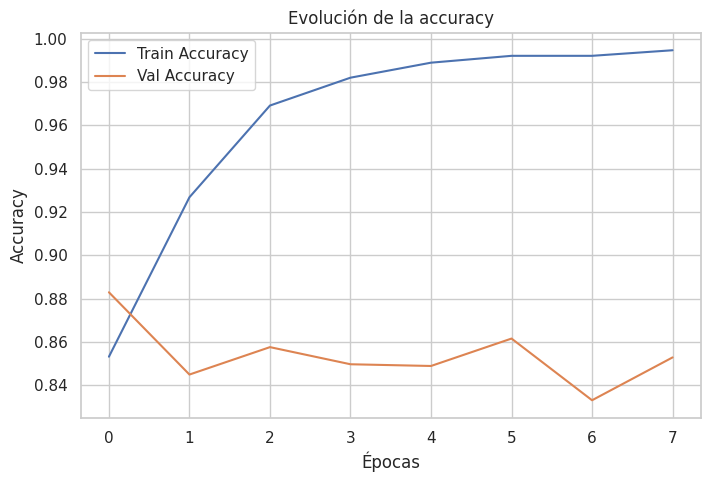

In [59]:
# ==========================================
# DEEP LEARNING CON PYTORCH
# ==========================================

# En esta etapa vamos a construir una red neuronal en PyTorch
# usando como entrada los vectores TF-IDF que ya generamos antes.
# Esto nos permite cumplir con la consigna de Deep Learning
# sin tener que cambiar toda la parte de limpieza y vectorización.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. PREPARACIÓN DE LOS DATOS PARA PYTORCH
# ==========================================

# Transformamos las etiquetas de texto ("positivo", "negativo")
# a números para que la red pueda trabajar con ellas.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Pasamos la matriz TF-IDF a formato denso y luego a tensores.
# PyTorch necesita tensores numéricos para entrenar la red.
X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

# Hacemos una división de entrenamiento y validación.
# Esto es importante porque el Early Stopping se controla
# mirando la pérdida sobre validación.
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_train_tensor
)

# Creamos datasets y dataloaders para trabajar por lotes (batches).
train_dataset = TensorDataset(X_train_final, y_train_final)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Datos preparados para PyTorch correctamente.")
print("Tamaño train:", len(train_dataset))
print("Tamaño validación:", len(val_dataset))
print("Tamaño test:", len(test_dataset))


# ==========================================
# 2. DEFINICIÓN DE LA RED NEURONAL
# ==========================================

# Creamos la clase TextClassifier como pide la consigna.
# La red recibe como entrada los vectores TF-IDF.
# Tiene dos capas ocultas, BatchNorm y Dropout en 0.5.
class TextClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TextClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.5)

        self.output = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.output(x)
        return x

# Definimos dimensiones de entrada y salida
input_dim = X_train_tensor.shape[1]
num_classes = len(le.classes_)

# Instanciamos el modelo
model = TextClassifier(input_dim=input_dim, num_classes=num_classes)

print(model)


# ==========================================
# 3. CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

# Definimos la función de pérdida y el optimizador.
# CrossEntropy es la indicada para clasificación multiclase o binaria codificada.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Detectamos si hay GPU disponible.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Entrenando en:", device)


# ==========================================
# 4. FUNCIÓN DE ENTRENAMIENTO Y VALIDACIÓN
# ==========================================

# Esta función recorre una época completa de entrenamiento.
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


# Esta función evalúa el modelo sin actualizar pesos.
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds


# ==========================================
# 5. ENTRENAMIENTO CON EARLY STOPPING
# ==========================================

# Early Stopping: si la loss de validación no mejora en 5 épocas,
# frenamos el entrenamiento para evitar sobreajuste.
num_epochs = 50
patience = 5

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Época {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict()
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early Stopping activado: se detiene el entrenamiento.")
        break

# Recuperamos el mejor modelo encontrado durante el entrenamiento
model.load_state_dict(best_model_state)


# ==========================================
# 6. EVALUACIÓN FINAL EN TEST
# ==========================================

test_loss, test_acc, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device)

print(f"\nLoss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

# Convertimos las clases numéricas nuevamente a sus nombres originales
y_true_labels = le.inverse_transform(y_true_test)
y_pred_labels = le.inverse_transform(y_pred_test)

print("\nClassification Report - Red Neuronal en PyTorch")
print(classification_report(y_true_labels, y_pred_labels))


# ==========================================
# 7. GRÁFICOS DEL ENTRENAMIENTO
# ==========================================

# Graficamos la evolución de la pérdida para ver si el modelo aprendió bien
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Graficamos la evolución de la accuracy
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [38]:
# Importamos el modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
# max_iter=1000 se usa para evitar problemas de convergencia
modelo_lr = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento vectorizados
modelo_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [39]:
# Realizamos predicciones sobre el conjunto de prueba
y_pred_lr = modelo_lr.predict(X_test_tfidf)

# Mostramos algunas predicciones como ejemplo
y_pred_lr[:10]

array(['positivo', 'positivo', 'negativo', 'positivo', 'positivo',
       'positivo', 'positivo', 'positivo', 'positivo', 'positivo'],
      dtype=object)

##Evaluación del modelo

Una vez entrenado el modelo, se evalúa su rendimiento utilizando distintas métricas.

Se analiza el accuracy, que representa el porcentaje de predicciones correctas, y también se utiliza el classification report, que permite evaluar el desempeño del modelo en cada clase.

Además, se genera una matriz de confusión para visualizar los aciertos y errores de manera más clara.

In [40]:
# Importamos métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Calculamos el accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Mostramos el resultado
print("Accuracy del modelo:", accuracy_lr)

Accuracy del modelo: 0.8848101265822785


In [41]:
# Mostramos el reporte completo
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negativo       0.90      0.24      0.38       232
    positivo       0.88      1.00      0.94      1348

    accuracy                           0.88      1580
   macro avg       0.89      0.62      0.66      1580
weighted avg       0.89      0.88      0.85      1580



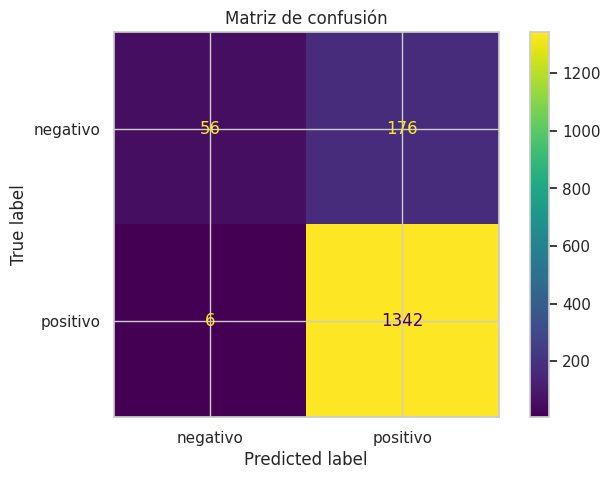

In [42]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_lr.classes_)
disp.plot()

plt.title("Matriz de confusión")
plt.show()

##Interpretación de resultados

El modelo obtuvo un accuracy cercano al 88%, lo que indica un buen desempeño general.

Sin embargo, al analizar en detalle las métricas, se observa un desbalance en la capacidad de predicción entre clases. En particular, el modelo presenta un alto recall para la clase positiva, pero un rendimiento considerablemente menor para la clase negativa.

Esto se debe a que el dataset se encuentra desbalanceado, con una mayor cantidad de reseñas positivas. Como consecuencia, el modelo tiende a predecir con mayor frecuencia la clase mayoritaria.

Por este motivo, resulta importante no evaluar el modelo únicamente mediante el accuracy, sino también considerar métricas como precision, recall y f1-score.

In [43]:
# Ajustamos el modelo para que tenga en cuenta el desbalance de clases
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

# Entrenamos nuevamente
modelo_lr.fit(X_train_tfidf, y_train)

# Predicciones nuevas
y_pred_lr = modelo_lr.predict(X_test_tfidf)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8512658227848101
              precision    recall  f1-score   support

    negativo       0.50      0.76      0.60       232
    positivo       0.96      0.87      0.91      1348

    accuracy                           0.85      1580
   macro avg       0.73      0.81      0.75      1580
weighted avg       0.89      0.85      0.86      1580



##Ajuste por desbalance de clases

Dado que el dataset presenta un desbalance entre clases, se ajustó el modelo utilizando el parámetro `class_weight='balanced'`.

Este ajuste permite que el modelo le otorgue mayor importancia a la clase minoritaria, mejorando su capacidad de detección.

Si bien el accuracy general disminuyó levemente, se observa una mejora significativa en el recall de la clase negativa, lo que indica un modelo más equilibrado y confiable.

Este tipo de ajuste es fundamental en problemas de clasificación desbalanceados.

##Entrenamiento de un segundo modelo

Para complementar el análisis, se entrena un segundo modelo utilizando el algoritmo Naive Bayes.

Este modelo es ampliamente utilizado en problemas de clasificación de texto debido a su simplicidad y buen desempeño en datos basados en frecuencia de palabras.

La comparación entre distintos modelos permite evaluar cuál se adapta mejor al problema planteado.

In [44]:
# Importamos el modelo Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Creamos el modelo
modelo_nb = MultinomialNB()

# Entrenamos el modelo
modelo_nb.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_nb = modelo_nb.predict(X_test_tfidf)

In [45]:
# Evaluamos el modelo
print("Accuracy Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes: 0.8563291139240506
              precision    recall  f1-score   support

    negativo       1.00      0.02      0.04       232
    positivo       0.86      1.00      0.92      1348

    accuracy                           0.86      1580
   macro avg       0.93      0.51      0.48      1580
weighted avg       0.88      0.86      0.79      1580



##Comparación de modelos

Se comparan los resultados obtenidos por los modelos de Regresión Logística y Naive Bayes para determinar cuál presenta mejor desempeño.

Esta comparación permite seleccionar el modelo más adecuado en función de métricas objetivas.

In [46]:
# Creamos una tabla comparativa
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Naive Bayes'],
    'Accuracy': [accuracy_lr, accuracy_score(y_test, y_pred_nb)]
})

resultados

,Modelo,Accuracy
0,Regresión Logística,0.884810
1,Naive Bayes,0.856329


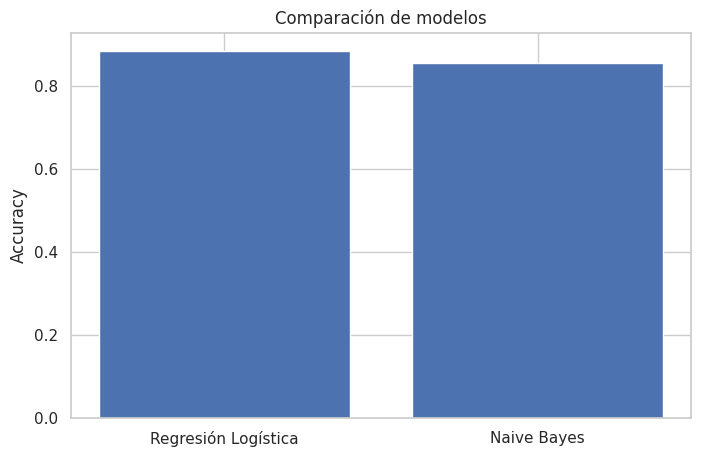

In [47]:
# Gráfico comparativo
import matplotlib.pyplot as plt

plt.bar(resultados['Modelo'], resultados['Accuracy'])
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.show()

##Interpretación de la comparación de modelos

A partir de los resultados obtenidos, se observa que el modelo de Regresión Logística presenta un mejor desempeño en términos de accuracy en comparación con Naive Bayes.

Si bien ambos modelos logran resultados satisfactorios, la Regresión Logística demuestra una mayor capacidad para capturar patrones en los datos y realizar predicciones más precisas.

Por este motivo, se selecciona la Regresión Logística como el modelo final para este problema de análisis de sentimiento.

##Prueba manual del modelo

Para validar el comportamiento del modelo, se realizan predicciones sobre nuevas reseñas que no forman parte del dataset original.

Esto permite comprobar si el modelo logra interpretar correctamente el sentimiento del texto en situaciones reales.

In [48]:
# Creamos nuevas reseñas para probar el modelo
nuevas_resenas = [
    "La película fue excelente, me encantó la historia",
    "Muy mala, aburrida y sin sentido",
    "No estuvo tan mal, pero esperaba más"
]

# Limpiamos las reseñas igual que hicimos antes
nuevas_resenas_limpias = [limpiar_texto(texto.lower()) for texto in nuevas_resenas]

# Las transformamos a formato numérico
nuevas_resenas_tfidf = tfidf.transform(nuevas_resenas_limpias)

# Hacemos predicciones
predicciones = modelo_lr.predict(nuevas_resenas_tfidf)

# Mostramos resultados
for resena, pred in zip(nuevas_resenas, predicciones):
    print("Reseña:", resena)
    print("Predicción:", pred)
    print("-" * 40)

Reseña: La película fue excelente, me encantó la historia
Predicción: positivo
----------------------------------------
Reseña: Muy mala, aburrida y sin sentido
Predicción: negativo
----------------------------------------
Reseña: No estuvo tan mal, pero esperaba más
Predicción: negativo
----------------------------------------


Los resultados obtenidos en las pruebas manuales muestran que el modelo logra interpretar correctamente el sentimiento de nuevas reseñas, incluso en casos intermedios o ambiguos, lo que valida su utilidad en escenarios reales.

##Conclusión

En este trabajo se desarrolló un modelo de análisis de sentimiento aplicado a reseñas de películas, utilizando técnicas de procesamiento de lenguaje natural y Machine Learning.

Se trabajó sobre distintas etapas, incluyendo la carga y exploración de datos, la limpieza del texto, la transformación mediante TF-IDF y el entrenamiento de modelos de clasificación.

Los resultados obtenidos fueron satisfactorios, logrando clasificar correctamente las reseñas en la mayoría de los casos. Además, se aplicaron ajustes para mejorar el rendimiento del modelo frente al desbalance de clases.

Por otro lado, la comparación entre distintos modelos permitió evaluar alternativas y seleccionar la más adecuada según el desempeño obtenido.

En conclusión, el análisis de sentimiento representa una herramienta útil para interpretar opiniones de manera automatizada, especialmente cuando se trabaja con grandes volúmenes de texto.

## Perspectivas futuras

Como líneas de mejora, se podrían incorporar modelos más avanzados de Deep Learning, como redes neuronales o modelos preentrenados de lenguaje.

También sería interesante trabajar con datasets más grandes o balanceados, así como ajustar hiperparámetros para mejorar el rendimiento del modelo.

Por último, se podrían explorar técnicas más avanzadas de procesamiento de texto para capturar mejor el contexto de las reseñas.